In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats, special
from typing import Callable

## Сгенерируем выборку ##

In [2]:
np.random.seed(42)
n = 25
data = np.random.exponential(scale=1.0, size=n)

## a) Найдем некоторые статистики ##

**Т.к. данные непрерывны, то мода всегда равна 0 (ну или каждый элемент считаем модным)**

In [3]:
print(f"Медиана: {np.median(data):.3f}")
print(f"Размах: {np.ptp(data):.3f}")
print(f"Асимметрия: {stats.skew(data):.3f}")

Медиана: 0.469
Размах: 3.483
Асимметрия: 1.700


## b) Построим графики ##

<Axes: >

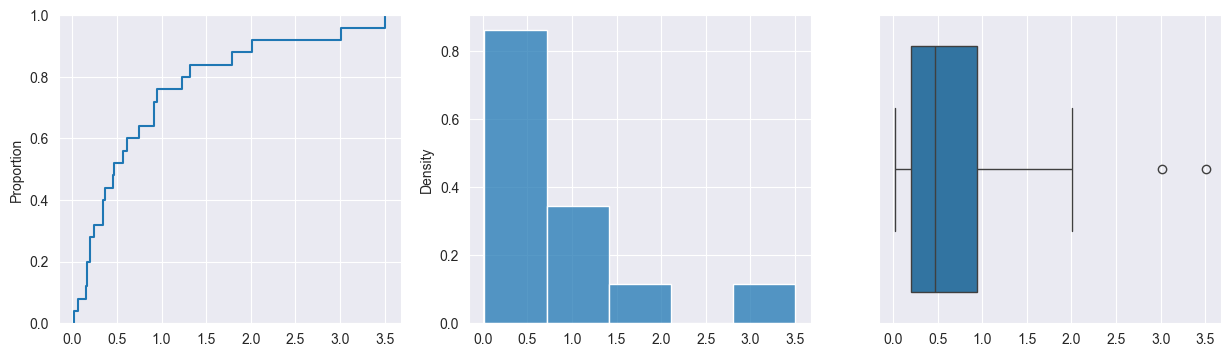

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4)) # для удобства всё на одном полотне

sns.ecdfplot(data, ax=axes[0]) # эмпирическая функция распределения
sns.histplot(data, stat="density", bins=int(1 + np.log2(n)),  kde=False, ax=axes[1]) # нормированная гистограмма
sns.boxplot(x=data, ax=axes[2])

## c) Сравним бутстрап с ЦПТ ##

In [5]:
# создадим функцию бутстрапа (аннотации скорее дело привычки, хоть они здесь и не нужны)
def bootstrap(func: Callable[[np.ndarray], float], i: int = 1000) -> np.ndarray:
    return np.array([func(np.random.choice(data, size=n, replace=True)) for _ in range(i)])

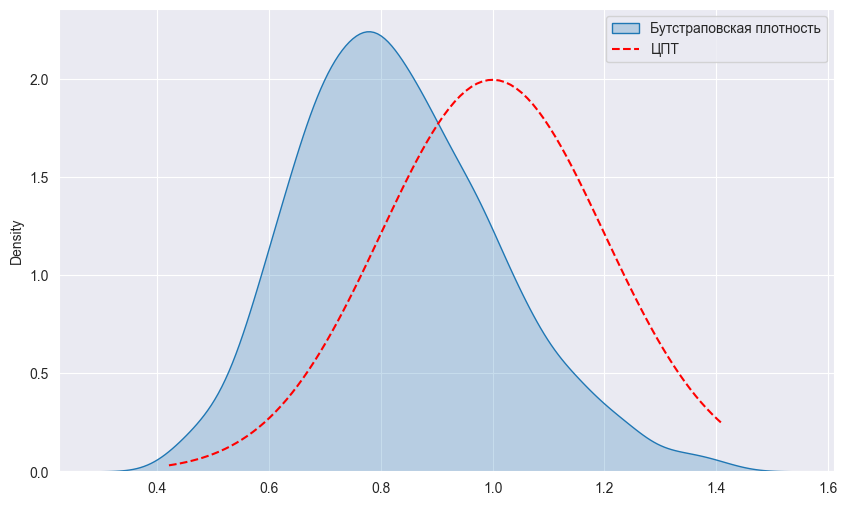

In [6]:
boots_means = bootstrap(np.mean) # просто массив из 100 средних по каждой подвыборке

# по цпт имеем нормальные распределения средних значений:
# Для p(x) = e^(-x) мат ожидание равно 1, дисперсия равна 1.
m_cpt = 1.0
sigma_cpt = np.sqrt(1.0 / n) # стандартное отклонение для графика среднего
cpt_x = np.linspace(min(boots_means), max(boots_means), 100)
cpt_y = stats.norm.pdf(cpt_x, loc=m_cpt, scale=sigma_cpt)

plt.figure(figsize=(10, 6))
sns.kdeplot(boots_means, fill=True, label='Бутстраповская плотность')
plt.plot(cpt_x, cpt_y, 'r--', label='ЦПТ')
plt.legend()

## d) Оценим ассиметрию и вероятности ##

In [7]:
boot_skew = bootstrap(stats.skew)
f"Оценка P(коэф асимметрии < 1) = {np.mean(boot_skew < 1)}"

'Оценка P(коэф асимметрии < 1) = 0.088'

Text(0.5, 1.0, 'Бутстраповское распределение асимметрии')

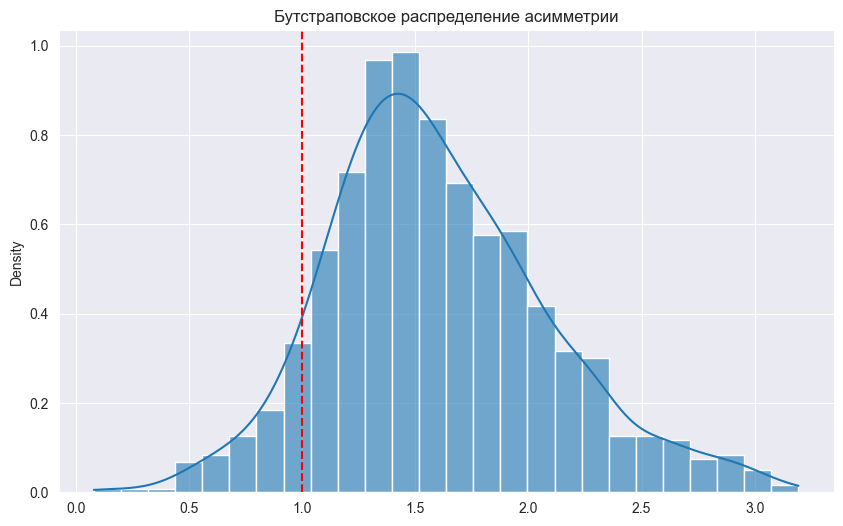

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(boot_skew, kde=True, stat="density", alpha=0.6)
plt.axvline(1, color='red', linestyle='--')
plt.title("Бутстраповское распределение асимметрии")

## e) Сравним плотность распределения медианы выборки с бутстраповской оценкой ##

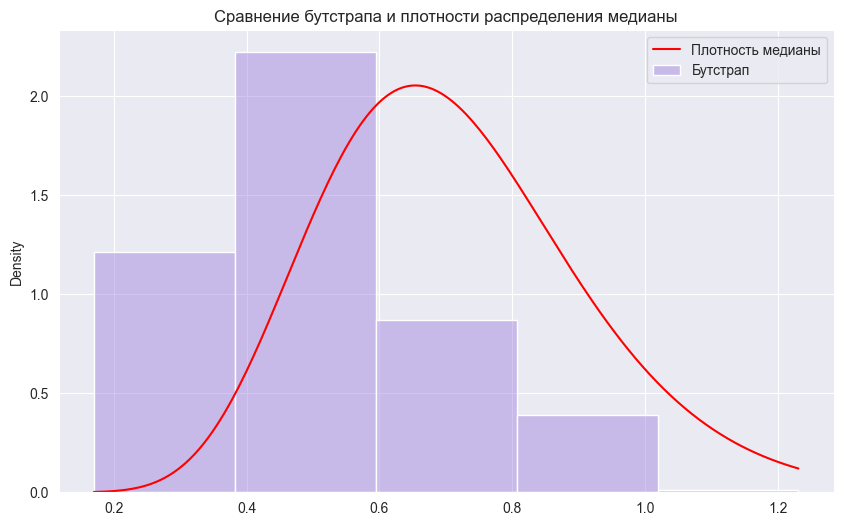

In [9]:
boot_meds = bootstrap(np.median)
k = (n + 1) // 2 # индекс медианы

def med_density(x):
    """
    Формула: n * C(n-1, k-1) * f(x) * F(x)^(k-1) * (1-F(x))^(n-k)
    """
    pdf = np.exp(-x)          # Плотность exp(-x)
    cdf = 1 - np.exp(-x)      # Функция распределения 1 - exp(-x)
    c = special.comb(n - 1, k - 1)

    return n * c * pdf * (cdf ** (k - 1)) * ((1 - cdf) ** (n - k))

plt.figure(figsize=(10, 6))
sns.histplot(boot_meds, stat="density", color="mediumpurple",
             alpha=0.4, label="Бутстрап", bins=int(1 + np.log2(n)))

meds_x = np.linspace(min(boot_meds), max(boot_meds), 200)
meds_y = med_density(meds_x)

plt.plot(meds_x, meds_y, color='red', label="Плотность медианы")

plt.title(f"Сравнение бутстрапа и плотности распределения медианы")
plt.legend()